In [50]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest, train_feature_weighted_decision_tree
from utils.gradient_ascent import compute_classification_metrics_gradient_ascent
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import sample, sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs_without_cv, mrs, \
    compute_feature_weights_with_budget, compute_feature_weights_with_temperature
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights

In [51]:
def compute_feature_weights_temperature(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance)) / len(feature_importance)
    else:
        weights =  np.exp(-feature_importance / budget)
    return weights / np.sum(weights)

def compute_feature_weights_with_budget(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        max_importance = np.max(feature_importance)
        min_importance = np.min(feature_importance)
        feature_importance = (feature_importance - min_importance)  / (max_importance - min_importance)
        scaled_feature_importance = feature_importance * budget
        scaled_feature_importance = 1 + scaled_feature_importance
        return scaled_feature_importance 

In [83]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
##N = df[df["label"] == 1]
#R = df[df["label"] == 0]
N, R = sample(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.5,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [84]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

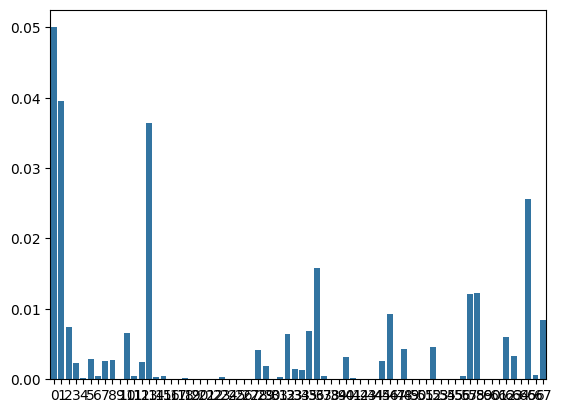

In [85]:
feature_weights = compute_feature_weights_with_budget(0.05, feature_importance_cv)
sns.barplot(feature_weights - 1)

In [86]:
seed = 5
max_features = "sqrt"
auroc_method = train_feature_weighted_random_forest
sample_weights = np.ones(len(N))
n_estimators=1000

feature_weights_list = []
budgets = [None, 0.01, 0.02, 0.05, 0.1]
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
for budget in budgets:
    # feature_weights = compute_feature_weights_with_temperature(budget, feature_importance_cv)
    feature_weights = compute_feature_weights_with_budget(budget, feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [87]:
for i, budget in enumerate(budgets):
   auroc = compute_test_metrics_fw_mrs(
       dropped_N,
       R,
       columns,
       random_state=seed,
       feature_weights=feature_weights_list[i],
       method=auroc_method,
       class_weight=None,
       max_features="sqrt",
       splitter="feature_weighted_best",
       n_splits_test=5,
       n_estimators=100,
       draw_with_feature_weights=False,
   )
   print(f"{budget}: {auroc}")

None: 0.5298801102483237
0.01: 0.5
0.02: 0.5
0.05: 0.5
0.1: 0.5


None: 0.6039460683178859\
0.02: 0.5912344888376883\
0.05: 0.5493763819797175\
0.1: 0.5242090747237785

In [88]:
for i,budget in enumerate(budgets):
    feature_weights = feature_weights_list[i]
    auroc, auprc = compute_classification_metrics_random_forest(
            N,
            R,
            columns,
            sample_weights,
            feature_weights,
            target,
            random_state=seed,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=200,
            draw_with_feature_weights=False,
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.8646068754165972
None AUPRC: 0.81936284815493

0.01 Auroc: 0.8647168831236459
0.01 AUPRC: 0.8199700404248903

0.02 Auroc: 0.86534698643976
0.02 AUPRC: 0.8206168036220459

0.05 Auroc: 0.8645434094317614
0.05 AUPRC: 0.8197786757022627

0.1 Auroc: 0.8591855784452591
0.1 AUPRC: 0.8126562437351458



In [58]:
for i,budget in enumerate(budgets):
    auroc, auprc = compute_classification_metrics_tree(
            N,
            R,
            columns,
            sample_weights,
            feature_weights_list[i],
            target,
            random_state=seed,
            draw_with_feature_weights=True,
            n_splits=10,
            splitter="feature_weighted_best",
            max_features="sqrt",
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.6933965675992158
None AUPRC: 0.6070694538809999

0.01 Auroc: 0.7541331321097008
0.01 AUPRC: 0.7091644326732004

0.02 Auroc: 0.6933965675992158
0.02 AUPRC: 0.6070694538809999

0.05 Auroc: 0.7477552943384349
0.05 AUPRC: 0.6856824623038243

0.1 Auroc: 0.6933965675992158
0.1 AUPRC: 0.6070694538809999



In [59]:
# dropped_N = dropped_N.drop(drop_ids)